## Function to generate data

Here, I use the same simulation framework as in the previous homework problem. The getData function takes several input arguments and returns the simulated dataset. The function has 11 input parameters and generates features for two classes. Specifically, n1 and n2 are vectors specifying the sample sizes of the two groups within each class, m1 and m0 denote the numbers of informative and uninformative predictors, respectively. The parameters x11 and x12 specify the mean vectors for the two components of class 1, while x21 and x22 specify the mean vectors for the two components of class 2. Finally, sd0 represents the standard deviation of the noise component for each predictor.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.random import multivariate_normal as mvn

def getData(n1, n2, m1, m0, x11, x12, x21, x22, sd0, plotY=True, returnDAT=True):
    '''
    n1           :  sample sizes in the two groups within each class
    n2           :  sample sizes in the two groups within each class 
    m1           :  number of informative predictors
    m0           :  number of uninformative predictor
    x11          :  vector of means for the two components of class 1 
    x12          :  vector of means for the two components of class 1 
    x21          :  vector of means for the two components of class 2 
    x22          :  vector of means for the two components of class 2 
    sd0          :  standard deviation of the noise component for each predict
    plotY        :  plot
    returnDAT    :  returns the dataset
    '''
    # means for each class and center
    mean11 = np.repeat(x11, m1 // 2)   # mean for class 1, center 1
    mean12 = np.repeat(x12, m1 // 2)   # mean for class 1, center 2
    mean21 = np.repeat(x21, m1 // 2)   # mean for class 2, center 1
    mean22 = np.repeat(x22, m1 // 2)   # mean for class 2 center 2
    
    cov = np.eye(m1) * (sd0**2)
    
    #create data for class 1
    X11 = mvn(mean11, cov, size=n1[0])
    X12 = mvn(mean12, cov, size=n1[1])
    
    #create data for class 2
    X21 = mvn(mean21, cov, size=n2[0])
    X22 = mvn(mean22, cov, size=n2[1])
    X = np.vstack([X11, X12, X21, X22])
        
    # noise variable
    if m0 > 0:
        noise = np.random.normal(0,scale=sd0,size=(sum(n1) + sum(n2), m0))
        X = np.hstack([X, noise])
    
    # add class variable to the first column
    y = np.concatenate([np.repeat(1, sum(n1)), np.repeat(2, sum(n2))])

    dat_out = pd.DataFrame(X)
    dat_out.insert(0, "v1", pd.Categorical(y))
    dat_out.columns = [f'v{i+1}' for i in range(dat_out.shape[1])]

    # plot features colored by class
    if plotY:
        colors = dat_out["v1"].map({1: 'black', 2: 'red'})
        plt.scatter(dat_out["v2"], dat_out.iloc[:, m1//2 + 1], edgecolors=colors, facecolor='none', s=40, alpha=0.7)
        plt.xlabel("feature 1")
        plt.ylabel(f"Feature {m1//2 + 2}")
        plt.show()

    if returnDAT:
        return dat_out

### Simulated data demo

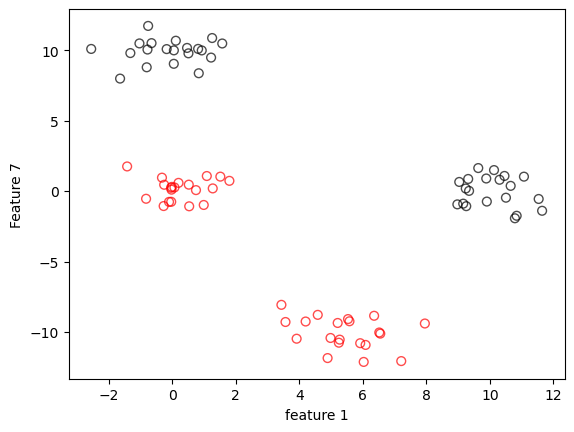

,v1,v2,v3,v4,v5,v6,v7,v8,v9,v10,v11
0,1,10.653307,9.554609,9.579496,8.668240,8.799144,0.369840,0.591713,0.238171,-0.133323,0.535248
1,1,10.304231,10.809505,8.846624,9.303523,11.320778,0.803012,0.357419,-0.333790,-1.313463,-0.738309
2,1,9.159778,9.820272,8.986914,10.533527,12.376103,-0.893343,0.047271,-0.045320,0.113187,-0.741079
3,1,9.316241,11.080239,12.034149,9.425649,9.060767,0.858785,1.695404,0.695971,1.716720,0.024377
4,1,8.975639,11.145046,8.999149,11.368706,10.773146,-0.943457,0.011478,-0.311006,1.848572,-1.540390
...,...,...,...,...,...,...,...,...,...,...,...
75,2,4.198602,5.288917,5.707186,5.211199,5.446652,-9.255877,-10.727165,-8.679067,-9.453287,-8.806979
76,2,6.086294,4.974949,6.833611,6.211446,4.126299,-10.917612,-9.764970,-9.875698,-9.083528,-9.972102
77,2,5.533339,5.359859,4.985571,6.033587,3.948870,-9.082518,-10.690999,-9.496051,-10.876300,-10.219821
78,2,7.951936,5.045426,6.705593,4.119695,6.604676,-9.397101,-9.412394,-8.753776,-10.555069,-9.278870


In [2]:
n1 = [20, 20]     # sample sizes in the two groups within each class
n2 = [20, 20]     # sample sizes in the two groups within each class
m1 = 10           # number of informative predictors 
m0 = 0            # number of uninformative predictor
x11 = [10, 0]     # vector of means for the two components of class 1 
x12 = [0, 10]     # vector of means for the two components of class 1 
x21 = [0, 0]      # vector of means for the two components of class 2
x22 = [5, -10]    # vector of means for the two components of class 2 
sd0 = 1           # standard deviation of the noise component for each predictor
plotY = True      # plot
returnDAT = True  # returns the dataset

getData(n1, n2, m1, m0, x11, x12, x21, x22, sd0, plotY = True, returnDAT = True)

## Hyperparameter Tuning for Decision Tree, Random Forest and AdaBoost Classifiers

In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import cross_val_score

def tune_alpha(X_train, y_train):
    '''
    This function takes the training data and selects the optimal value of alpha
    using 5-fold cross-validation, which is then used to prune the decision tree.
    '''
    
    base_model = DecisionTreeClassifier() # create a tree object
    path = base_model.cost_complexity_pruning_path(X_train, y_train) # fit the model with the training data
    
    scores = []
    # fit each alpha and perform 5-fold cross-validation
    for alpha in path.ccp_alphas:
        model = DecisionTreeClassifier(ccp_alpha=alpha)
        # perform cross validation
        score = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy').mean() # store the mean CV score
        scores.append(score)
    
    best_alpha = path.ccp_alphas[np.argmax(scores)] # get the best alpha
    
    return best_alpha

# fine-tune the Random Forest and AdaBoost classifiers
def tune_params(X_train, y_train, clf, params):

    '''
    Perform hyperparameter tuning on the classifier using training data 
    and return the optimal fitted model
    '''
    grid = RandomizedSearchCV(
        clf,
        #param_grid = params,
        param_distributions=params,
        scoring='accuracy',
        cv=5,
        n_iter=5,
        n_jobs=-1,
    )

    grid.fit(X_train, y_train)
    model = grid.best_estimator_  
    
    return model

## Function to simulate classification accuracy

The function class_sim computes the classification accuracy for a single decision tree, a pruned decision tree, a random forest, and AdaBoost across multiple replicate datasets. At each replicate, it generates training and test data using the getData function, fits all models to the training data, and evaluates their classification accuracy on the test data.

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

def class_sim(nrep,n1,n2,m1,m0,x11,x12,x21,x22,sd0):
    
    single_tree_acc = []
    pruned_tree_acc = []
    rf_acc = []
    ada_acc = []
    
    # list of parameters to fine-tune Random Forest and AdaBoost
    rf_params = {
        'n_estimators': [100, 200, 300], # number of trees
        'max_depth': [10, 20, 30, None], # maximum depth of each tree
        'max_features': ['sqrt', 'log2'], # number of features considered at each split
        'min_samples_split': [2, 5, 10], # minimum number of samples required to split a node
    }
    
    ada_params = {
        'n_estimators': [50, 100, 200], # number of weak learners
        'learning_rate': [0.5, 1.0, 1.5] # each learner’s contribution
    }

    for i in range(nrep):
        # generate data
        train_data = getData(n1,n2,m1,m0,x11,x12,x21,x22,sd0,False,True)
        test_data = getData(n1,n2,m1,m0,x11,x12,x21,x22,sd0,False,True)
        
        # split into training and test sets
        X_train = train_data.iloc[:, 1:]
        y_train = train_data.iloc[:, 0]
        X_test = test_data.iloc[:, 1:]
        y_test = test_data.iloc[:, 0]
        
        # fit single tree
        single_tree = DecisionTreeClassifier()
        single_tree.fit(X_train, y_train)
        y_pred = single_tree.predict(X_test)
        single_tree_acc.append(accuracy_score(y_test, y_pred))
        
        # fit pruned tree
        best_alpha = tune_alpha(X_train, y_train)
        pruned_tree = DecisionTreeClassifier(ccp_alpha=best_alpha)
        pruned_tree.fit(X_train, y_train)
        y_pred = pruned_tree.predict(X_test)
        pruned_tree_acc.append(accuracy_score(y_test, y_pred))
        
        # fit random forest
        rf = tune_params(X_train, y_train, RandomForestClassifier(), rf_params)
        y_pred = rf.predict(X_test)
        rf_acc.append(accuracy_score(y_test, y_pred))

        # fit adaboost
        ada = tune_params(X_train, y_train, AdaBoostClassifier(), ada_params)
        y_pred = ada.predict(X_test)
        ada_acc.append(accuracy_score(y_test, y_pred))
        
    single_tree_acc = np.array(single_tree_acc)
    pruned_tree_acc = np.array(pruned_tree_acc)
    rf_acc = np.array(rf_acc)
    ada_acc = np.array(ada_acc)
        
    # plot accuracy distribution
    plt.hist(single_tree_acc, density=True)
    plt.title("Single Tree classification accuracy")
    plt.xlabel("classification accuracy")
    plt.show()

    plt.hist(pruned_tree_acc, density=True)
    plt.title("Pruned Tree classification accuracy")
    plt.xlabel("classification accuracy")
    plt.show()

    plt.hist(rf_acc, density=True)
    plt.title("Random Forest classification accuracy")
    plt.xlabel("classification accuracy")
    plt.show()

    plt.hist(ada_acc, density=True)
    plt.title("AdaBoost classification accuracy")
    plt.xlabel("classification accuracy")
    plt.show()
        
    summary = {
        "single_tree": pd.Series(single_tree_acc).describe(),
        "pruned_tree": pd.Series(pruned_tree_acc).describe(),
        "rf": pd.Series(rf_acc).describe(),
        "ada": pd.Series(ada_acc).describe()
    }
    
    return pd.DataFrame(summary).T

## Scenario 1: Gaussia 

### Case 1: Classification with 20 Informative Variables and No Noise Variables

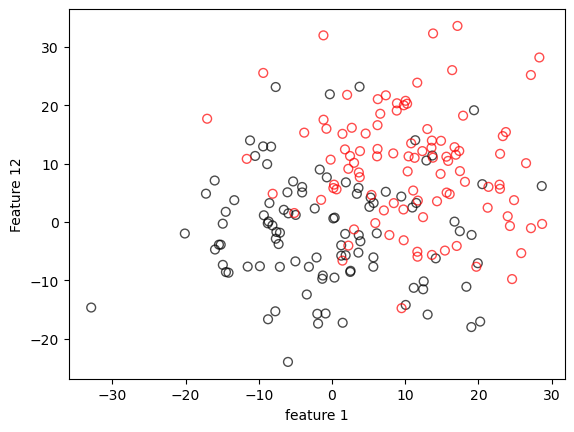

In [5]:
nrep = 50         # number of replicates
n1 = [50, 50]     # sample sizes in the two groups within each class
n2 = [50, 50]     # sample sizes in the two groups within each class
m1 = 20           # number of informative predictors 
m0 = 0            # number of uninformative predictor
x11 = [0,0]       # vector of means for the two components of class 1 
x12 = [0,0]       # vector of means for the two components of class 1 
x21 = [10,10]     # vector of means for the two components of class 2
x22 = [10,10]     # vector of means for the two components of class 2 
sd0 = 10         # standard deviation of the noise component for each predictor

getData(n1, n2, m1, m0, x11, x12, x21, x22, sd0, plotY = True, returnDAT = False)

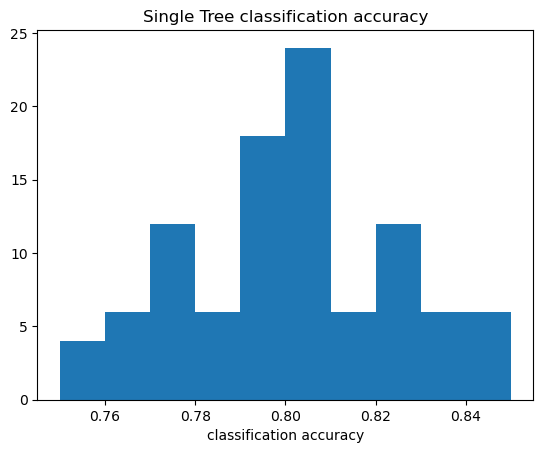

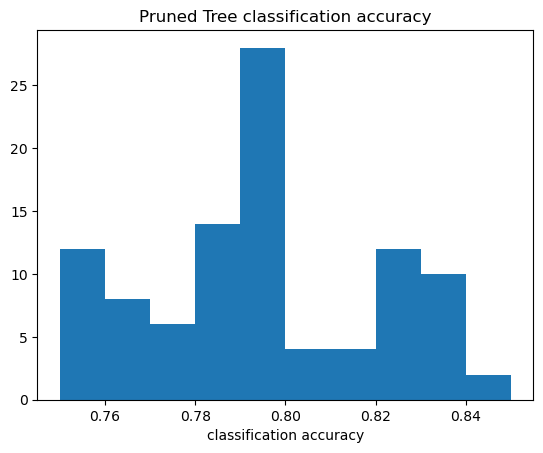

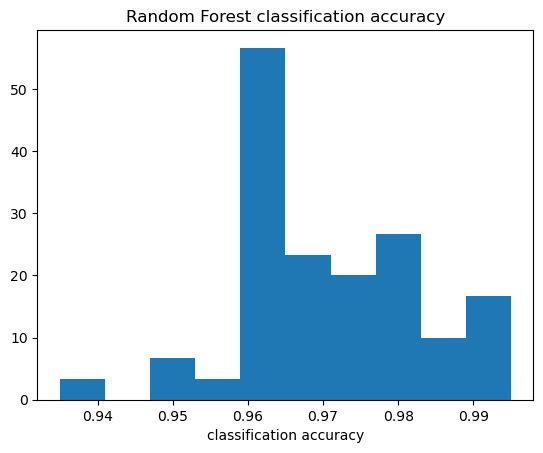

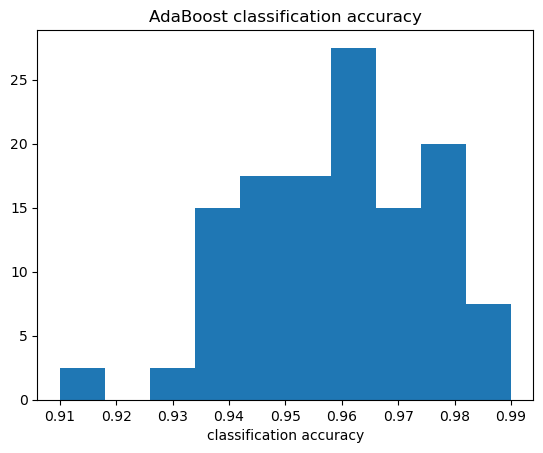

,count,mean,std,min,25%,50%,75%,max
single_tree,50.0,0.7992,0.024523,0.750,0.78125,0.8025,0.81375,0.850
pruned_tree,50.0,0.7929,0.025933,0.750,0.77625,0.7900,0.81375,0.850
rf,50.0,0.9709,0.012523,0.935,0.96000,0.9700,0.98000,0.995
ada,50.0,0.9590,0.016629,0.910,0.94500,0.9600,0.97000,0.990


In [6]:
class_sim(nrep, n1, n2, m1, m0, x11, x12, x21, x22, sd0)  

Here, we observe that Random Forest achieved the highest mean classification accuracy, with AdaBoost performing closely behind. The decision tree performed less well, achieving an mean accuracy of approximately 79%–80%.

### Case 2: Classification with 20 Informative and 20 Noise Variables

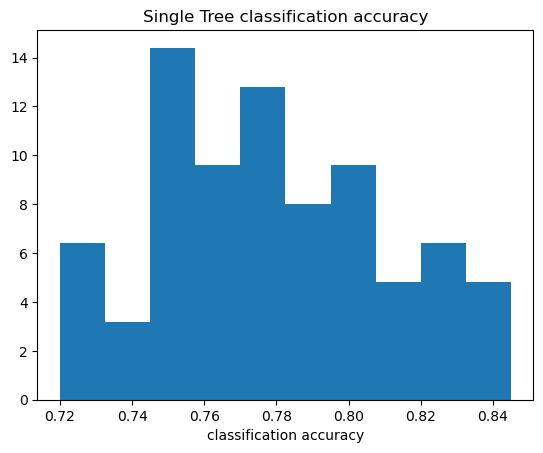

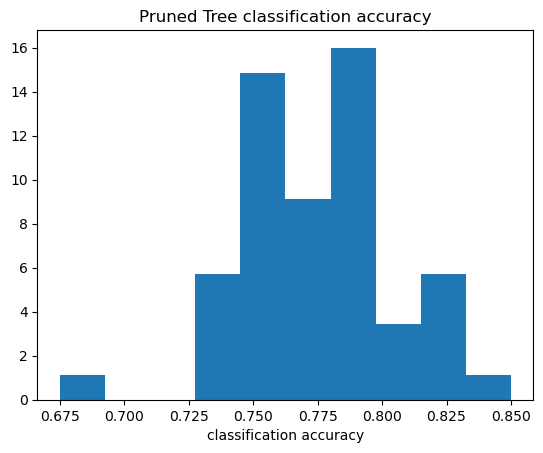

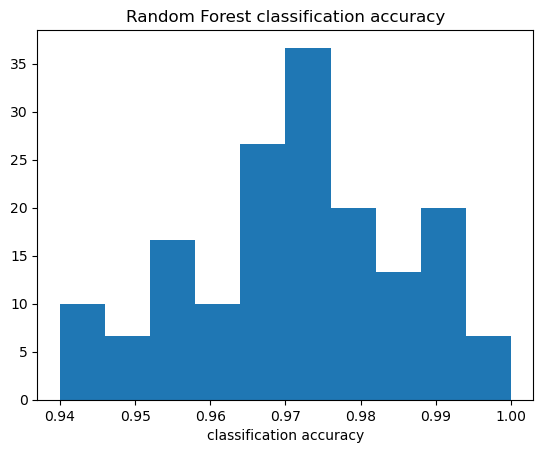

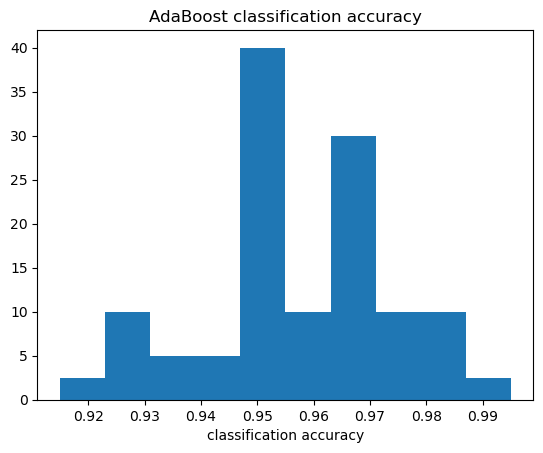

,count,mean,std,min,25%,50%,75%,max
single_tree,50.0,0.7784,0.032015,0.720,0.75500,0.7750,0.800,0.845
pruned_tree,50.0,0.7744,0.031309,0.675,0.75500,0.7725,0.795,0.850
rf,50.0,0.9709,0.014310,0.940,0.96125,0.9700,0.980,1.000
ada,50.0,0.9579,0.016540,0.915,0.95000,0.9575,0.970,0.995


In [7]:
nrep = 50
n1 = [50, 50]
n2 = [50, 50]
m1 = 20
m0 = 20
x11 = [0, 0]
x12 = [0, 0]
x21 = [10, 10]
x22 = [10, 10]
sd0 = 10

class_sim(nrep, n1, n2, m1, m0, x11, x12, x21, x22, sd0)  

When 20 noise variables are added, Random Forest and AdaBoost still achieve high mean accuracy.

### Case 3: Classification with 20 Informative and 10 Noise Variables

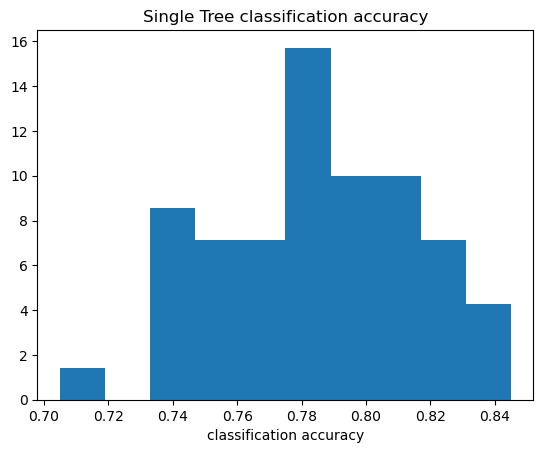

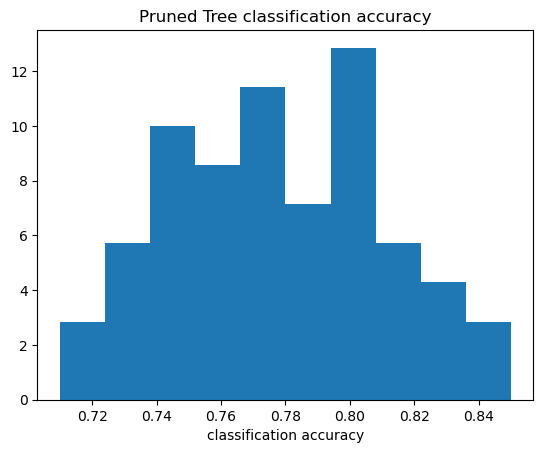

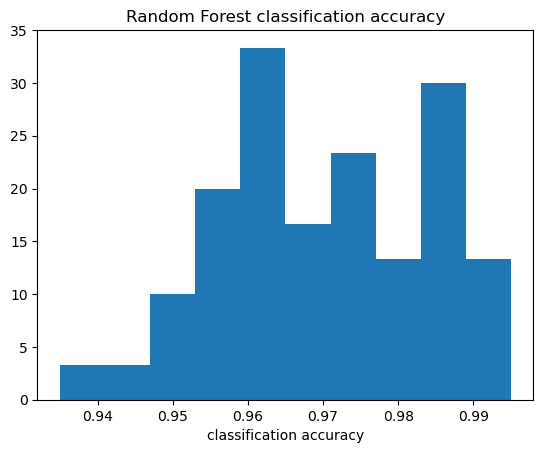

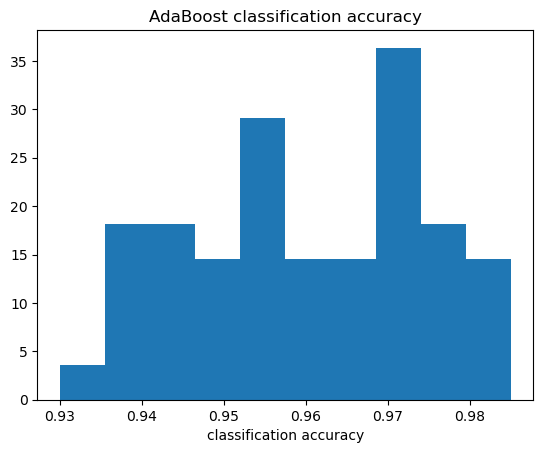

,count,mean,std,min,25%,50%,75%,max
single_tree,50.0,0.7854,0.030403,0.705,0.77000,0.785,0.80500,0.845
pruned_tree,50.0,0.7777,0.032674,0.710,0.75250,0.775,0.80000,0.850
rf,50.0,0.9706,0.013874,0.935,0.96125,0.970,0.98375,0.995
ada,50.0,0.9601,0.013646,0.930,0.95000,0.960,0.97000,0.985


In [8]:
nrep = 50
n1 = [50, 50]
n2 = [50, 50]
m1 = 20
m0 = 10
x11 = [0, 0]
x12 = [0, 0]
x21 = [10, 10]
x22 = [10, 10]
sd0 = 10

class_sim(nrep, n1, n2, m1, m0, x11, x12, x21, x22, sd0)  

With 10 noise variables, Random Forest still achieves about 97% mean accuracy and AdaBoost about 96%, while the decision tree achieves around 78%–79%.

### Case 4: Classification with 20 Informative and 5 Noise Variables

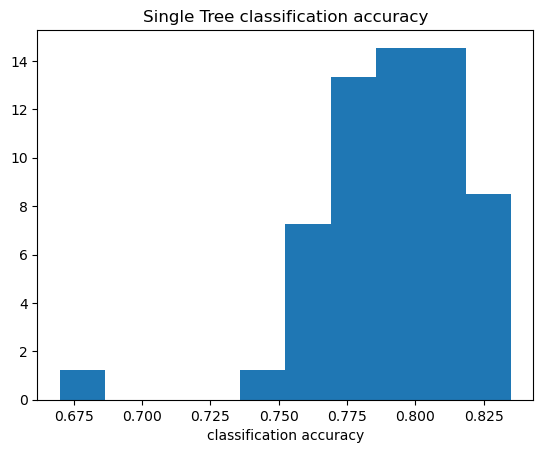

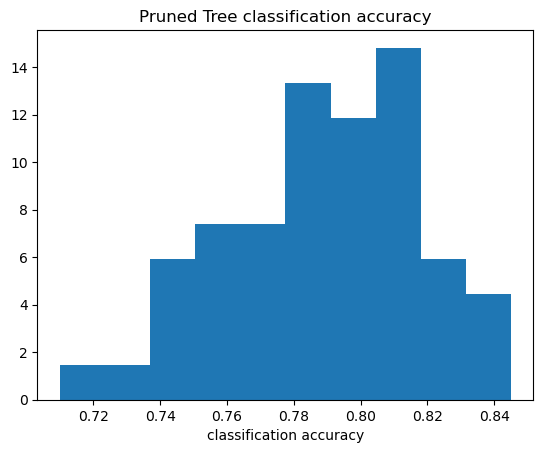

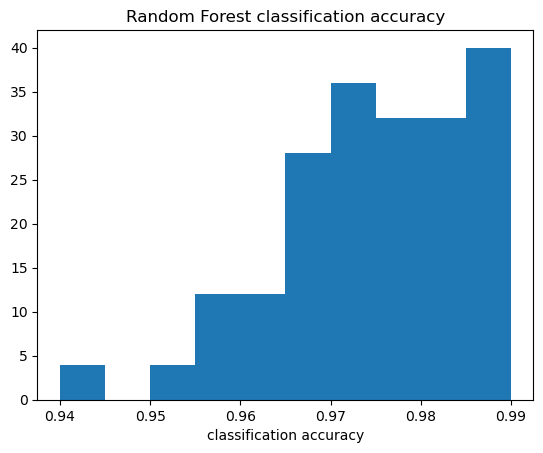

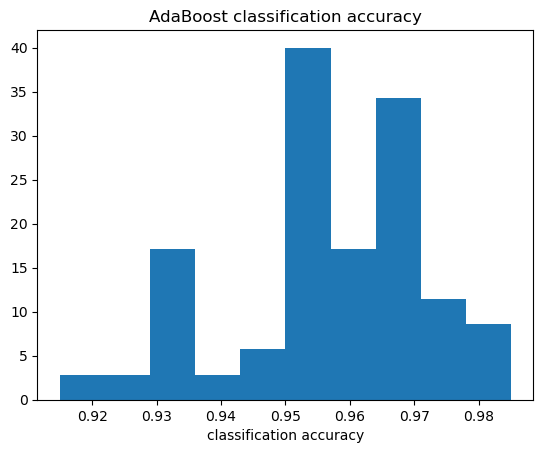

,count,mean,std,min,25%,50%,75%,max
single_tree,50.0,0.7922,0.027741,0.670,0.780,0.7950,0.810,0.835
pruned_tree,50.0,0.7884,0.028561,0.710,0.775,0.7925,0.805,0.845
rf,50.0,0.9723,0.010700,0.940,0.965,0.9750,0.980,0.990
ada,50.0,0.9563,0.015413,0.915,0.950,0.9575,0.965,0.985


In [9]:
nrep = 50
n1 = [50, 50]
n2 = [50, 50]
m1 = 20
m0 = 5
x11 = [0, 0]
x12 = [0, 0]
x21 = [10, 10]
x22 = [10, 10]
sd0 = 10

class_sim(nrep, n1, n2, m1, m0, x11, x12, x21, x22, sd0)  

With 5 noise variables, Random Forest and AdaBoost achieve similar accuracy, while the decision tree performs approximately 18% worse.

### Case 5: Classification with 20 Informative and 3 Noise Variables

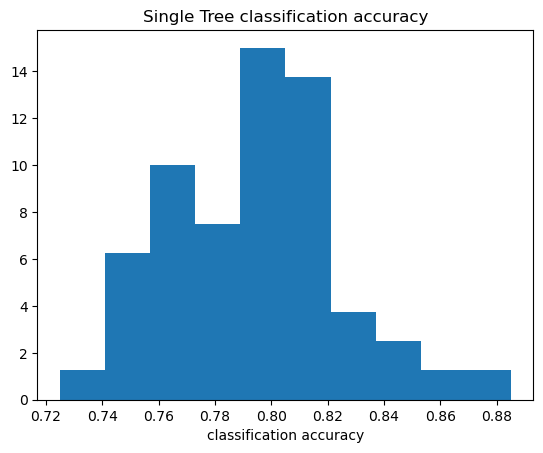

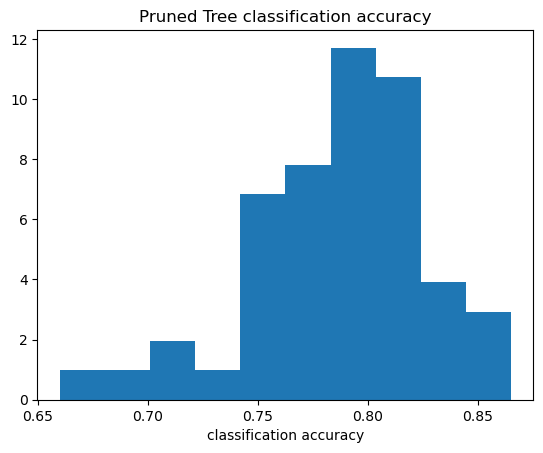

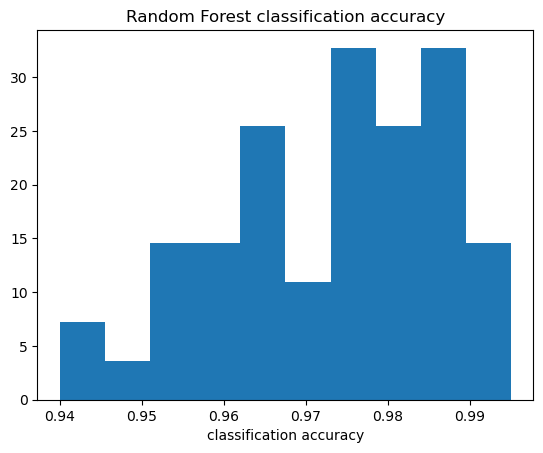

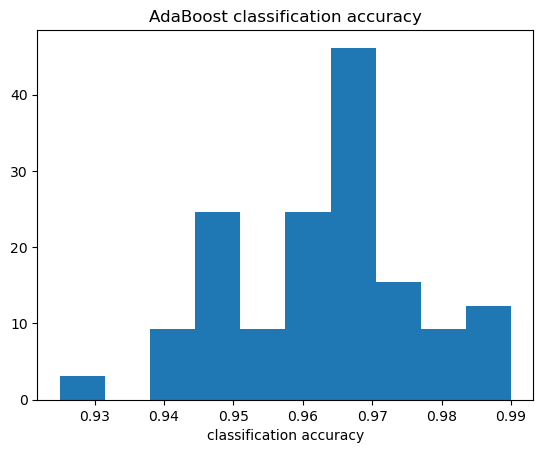

,count,mean,std,min,25%,50%,75%,max
single_tree,50.0,0.7936,0.030955,0.725,0.770,0.795,0.80875,0.885
pruned_tree,50.0,0.7852,0.039395,0.660,0.765,0.790,0.80500,0.865
rf,50.0,0.9725,0.012667,0.940,0.965,0.975,0.98375,0.995
ada,50.0,0.9633,0.013576,0.925,0.955,0.965,0.97000,0.990


In [10]:
nrep = 50
n1 = [50, 50]
n2 = [50, 50]
m1 = 20
m0 = 3
x11 = [0, 0]
x12 = [0, 0]
x21 = [10, 10]
x22 = [10, 10]
sd0 = 10

class_sim(nrep, n1, n2, m1, m0, x11, x12, x21, x22, sd0)  

With 3 noise variables, Random Forest achieves about 97% mean accuracy and AdaBoost about 96%, while the decision tree achieves around 79%.

### Case 6: Classification with 20 Informative and 100 Noise Variables

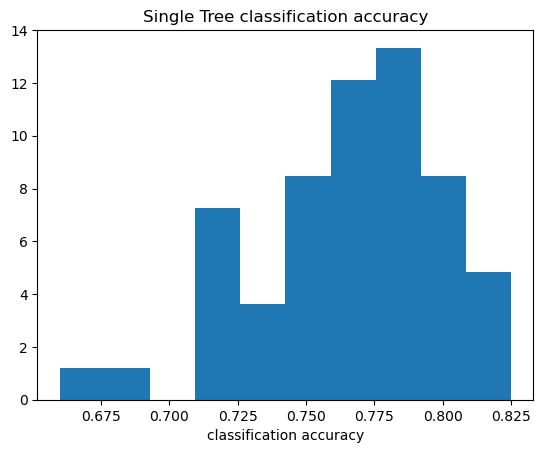

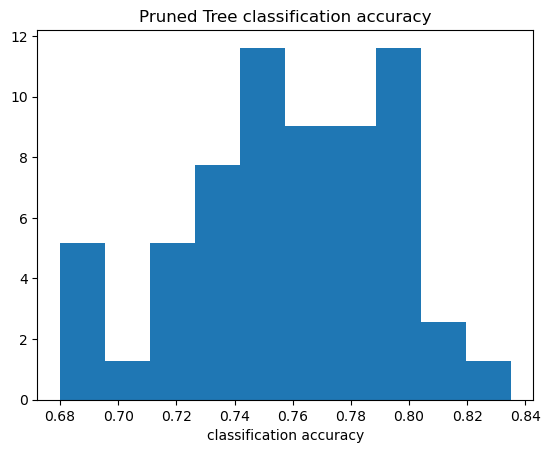

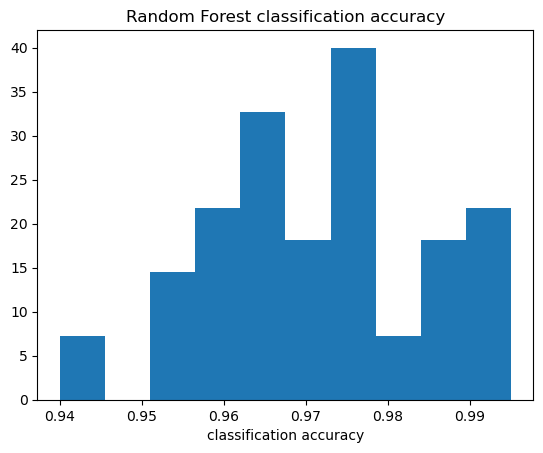

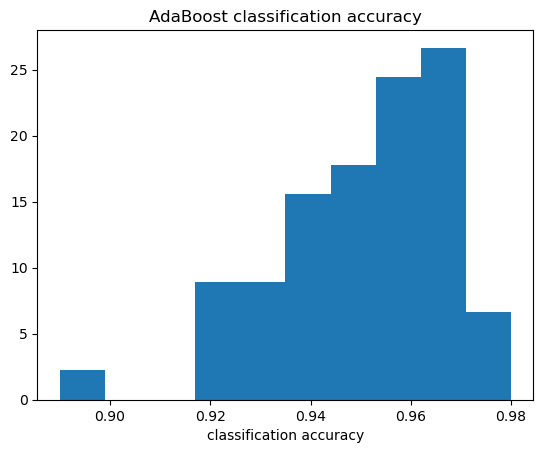

,count,mean,std,min,25%,50%,75%,max
single_tree,50.0,0.7665,0.034777,0.66,0.74625,0.7750,0.79000,0.825
pruned_tree,50.0,0.7581,0.036308,0.68,0.73500,0.7625,0.78375,0.835
rf,50.0,0.9711,0.012301,0.94,0.96500,0.9700,0.97875,0.995
ada,50.0,0.9503,0.017855,0.89,0.93625,0.9550,0.96500,0.980


In [11]:
nrep = 50
n1 = [50, 50]
n2 = [50, 50]
m1 = 20
m0 = 100
x11 = [0, 0]
x12 = [0, 0]
x21 = [10, 10]
x22 = [10, 10]
sd0 = 10

class_sim(nrep, n1, n2, m1, m0, x11, x12, x21, x22, sd0)

Even with 100 noise variables, Random Forest and AdaBoost still achieve high accuracy, outperforming both the single and pruned decision trees.

## Scenario 2: Gaussian Mixture

### Case 1: Classification with 20 Informative Variables and No Noise Variables

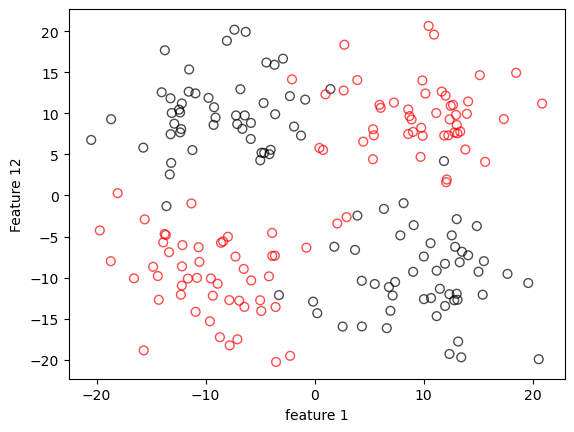

In [12]:
# highly separable data
nrep = 50
n1 = [50, 50]
n2 = [50, 50]
m1 = 20
m0 = 0
x11 = [-10, 10]
x12 = [10, -10]
x21 = [-10, -10]
x22 = [10, 10]
sd0 = 5

getData(n1, n2, m1, m0, x11, x12, x21, x22, sd0, plotY = True, returnDAT = False)

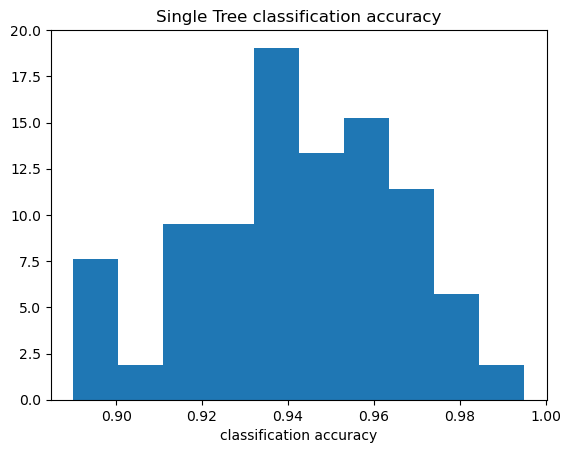

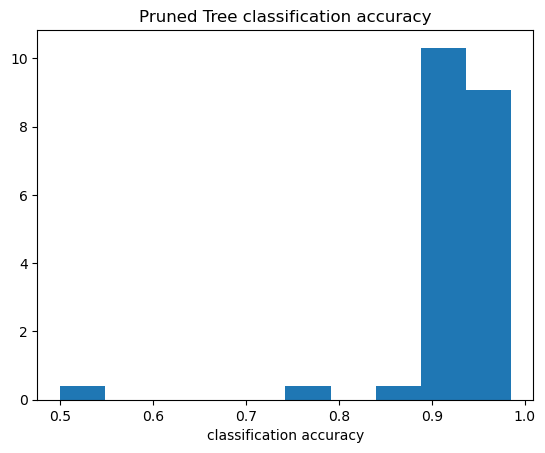

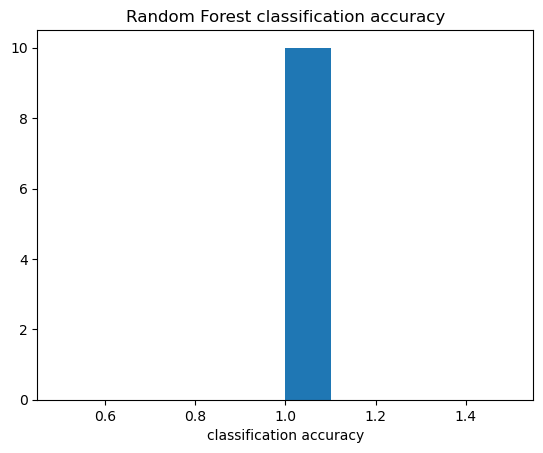

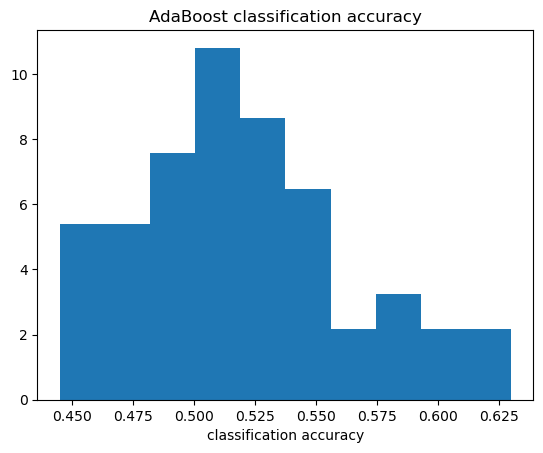

,count,mean,std,min,25%,50%,75%,max
single_tree,50.0,0.9421,0.022702,0.890,0.93,0.9425,0.95500,0.995
pruned_tree,50.0,0.9244,0.069191,0.500,0.92,0.9350,0.95375,0.985
rf,50.0,1.0000,0.000000,1.000,1.00,1.0000,1.00000,1.000
ada,50.0,0.5200,0.045468,0.445,0.49,0.5150,0.54000,0.630


In [13]:
class_sim(nrep, n1, n2, m1, m0, x11, x12, x21, x22, sd0)

For a high-separation Gaussian mixture, Random Forest achieved 100% mean accuracy, while a single decision tree ranged from 92% to 94%. However, AdaBoost performed poorly on this dataset, achieving only about 52% mean accuracy.

### Case 2: Classification with 20 Informative Variables and No Noise Variables

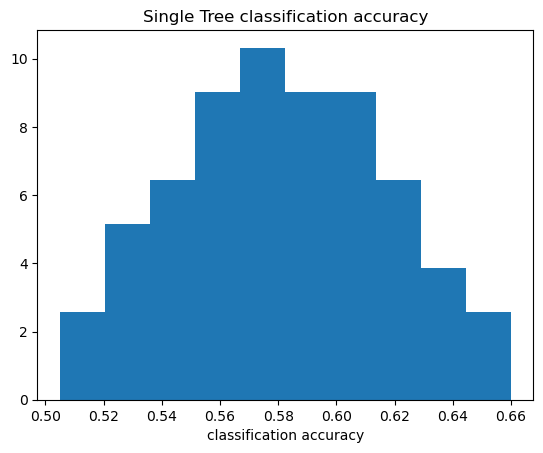

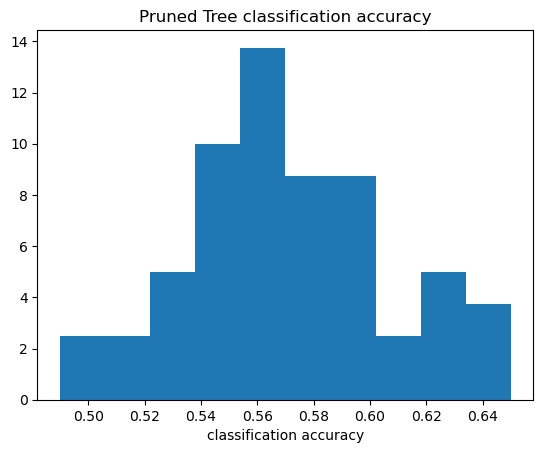

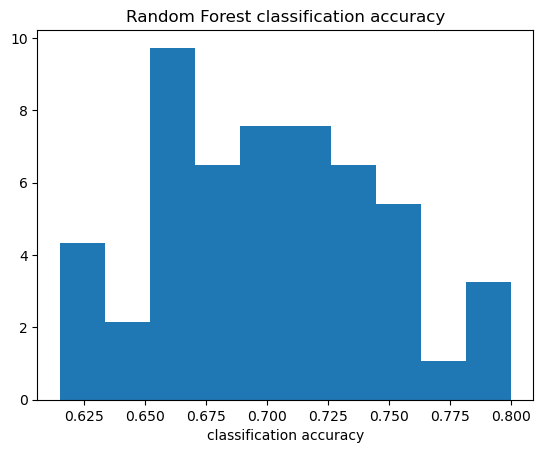

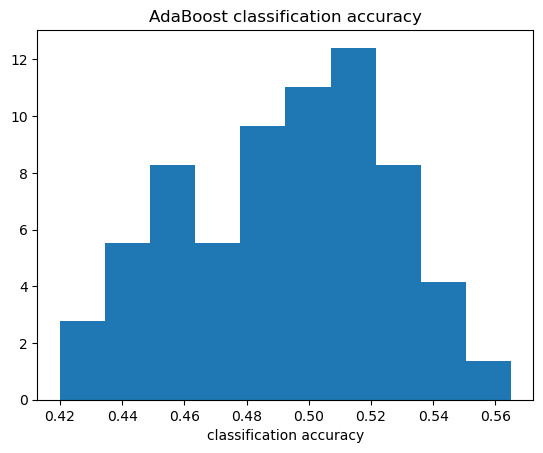

,count,mean,std,min,25%,50%,75%,max
single_tree,50.0,0.5815,0.035560,0.505,0.55500,0.5800,0.605,0.660
pruned_tree,50.0,0.5707,0.036225,0.490,0.54625,0.5675,0.595,0.650
rf,50.0,0.7003,0.044474,0.615,0.66500,0.7000,0.730,0.800
ada,50.0,0.4934,0.034794,0.420,0.46625,0.4975,0.520,0.565


In [14]:
# close cluster centers with high variance
nrep = 50
n1 = [50, 50]
n2 = [50, 50]
m1 = 20
m0 = 0
x11 = [-5, 5]
x12 = [5, -5]
x21 = [-5, -5]
x22 = [5, 5]
sd0 = 10

class_sim(nrep, n1, n2, m1, m0, x11, x12, x21, x22, sd0)

With high variance, accuracy drops significantly across all models. However, Random Forest outperforms the other models in this case.

### Case 3: Classification with 20 Informative Variables and No Noise Variables

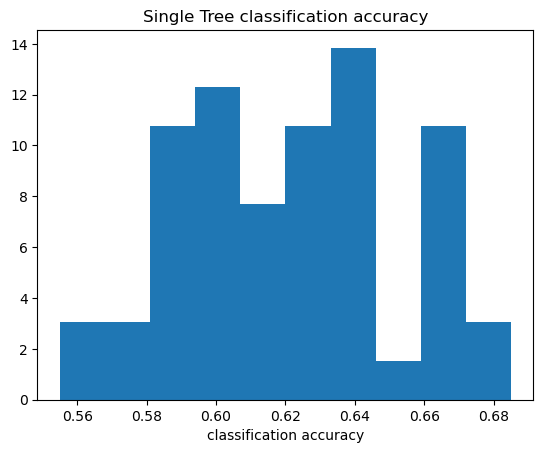

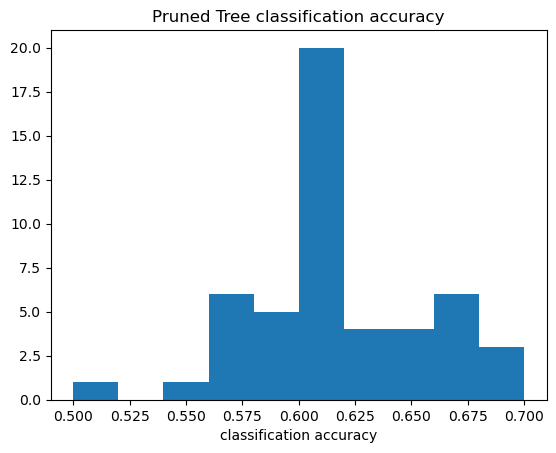

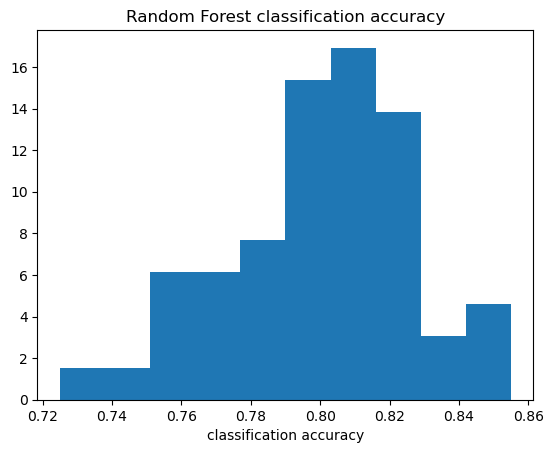

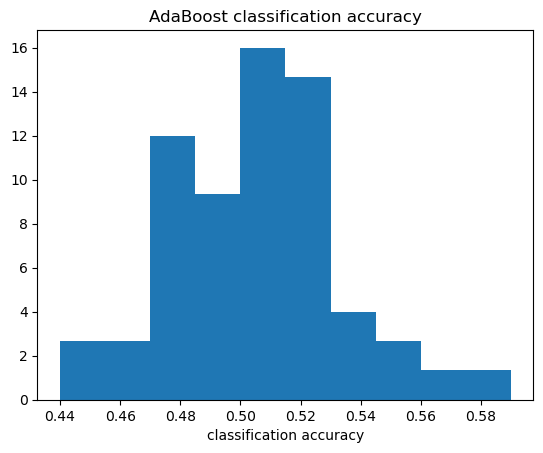

,count,mean,std,min,25%,50%,75%,max
single_tree,50.0,0.6220,0.031412,0.555,0.60000,0.6250,0.64375,0.685
pruned_tree,50.0,0.6152,0.038119,0.500,0.59625,0.6125,0.63750,0.700
rf,50.0,0.7994,0.027491,0.725,0.78500,0.8025,0.82000,0.855
ada,50.0,0.5025,0.028558,0.440,0.48125,0.5025,0.51875,0.590


In [15]:
# strong overlap between classes
nrep = 50
n1 = [50, 50]
n2 = [50, 50]
m1 = 20
m0 = 0
x11 = [-3, 3]
x12 = [3, -3]
x21 = [-3, -3]
x22 = [3, 3]
sd0 = 5
class_sim(nrep, n1, n2, m1, m0, x11, x12, x21, x22, sd0)

When we increase the data complexity, AdaBoost performs closer to random guessing, while the decision tree outperforms AdaBoost, achieving 61%–62% accuracy. Random Forest still performs best, achieving around 80% accuracy.

### Case 4: Classification with 20 Informative Variables and No Noise Variables

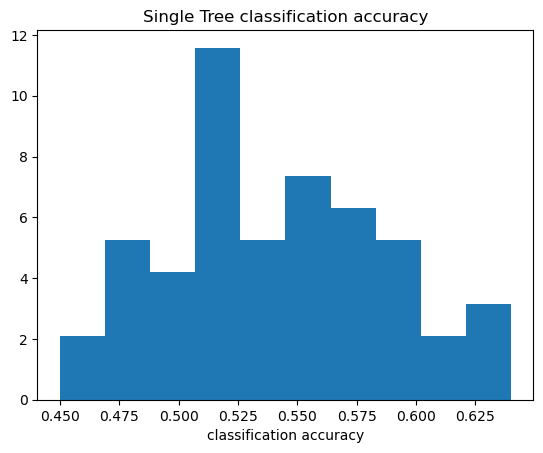

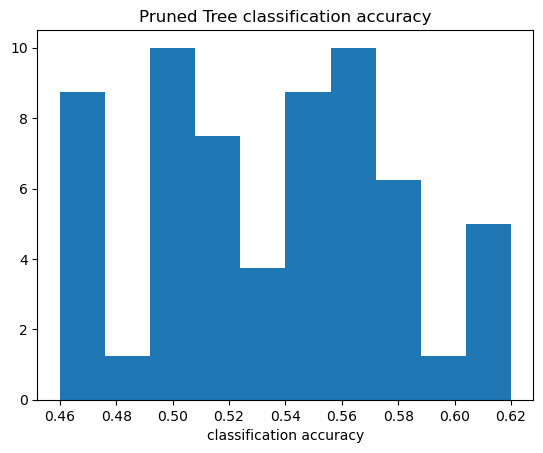

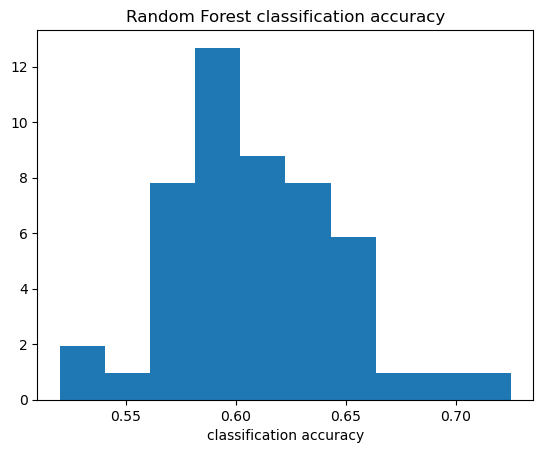

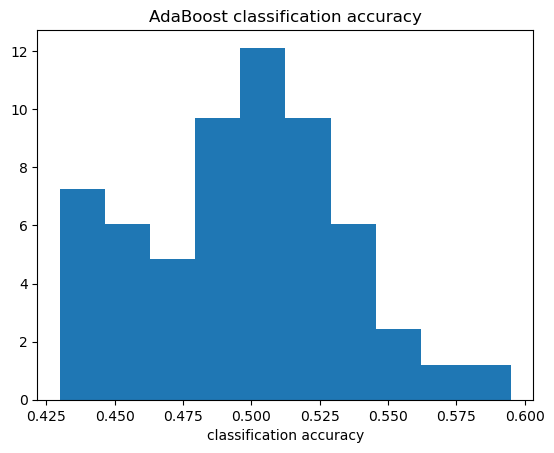

,count,mean,std,min,25%,50%,75%,max
single_tree,50.0,0.5414,0.046324,0.45,0.51000,0.5350,0.575,0.640
pruned_tree,50.0,0.5354,0.043727,0.46,0.50000,0.5375,0.570,0.620
rf,50.0,0.6081,0.038131,0.52,0.58500,0.6050,0.625,0.725
ada,50.0,0.4964,0.038306,0.43,0.46625,0.5025,0.520,0.595


In [16]:
# high overlap between classes
nrep = 50
n1 = [50, 50]
n2 = [50, 50]
m1 = 20
m0 = 0
x11 = [-2, 2]
x12 = [2, -2]
x21 = [-2, -2]
x22 = [2, 2]
sd0 = 5

class_sim(nrep, n1, n2, m1, m0, x11, x12, x21, x22, sd0)

When we further increase the data complexity, the performance of all models drops significantly. However, Random Forest still outperforms the others, achieving around 61% accuracy, while the decision tree performs only slightly better than random guessing, and AdaBoost performs similarly to random chance.

### Case 5: Classification with 20 Informative and 50 Noise Variables

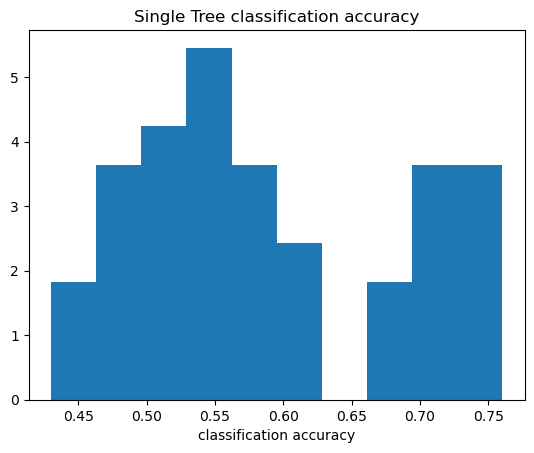

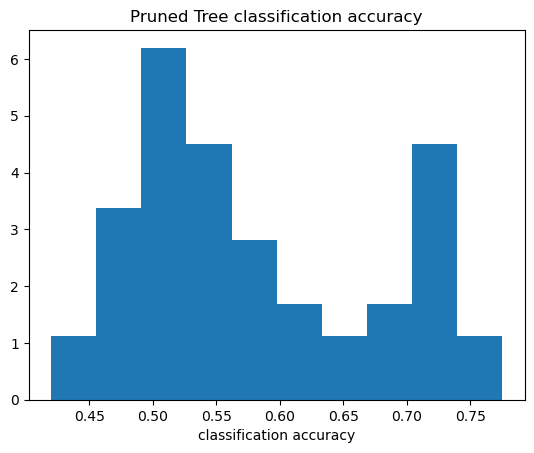

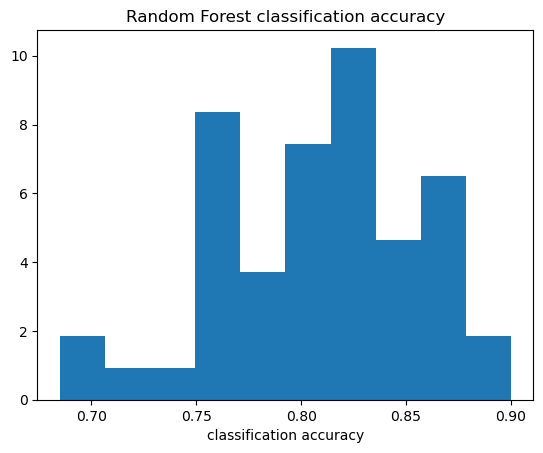

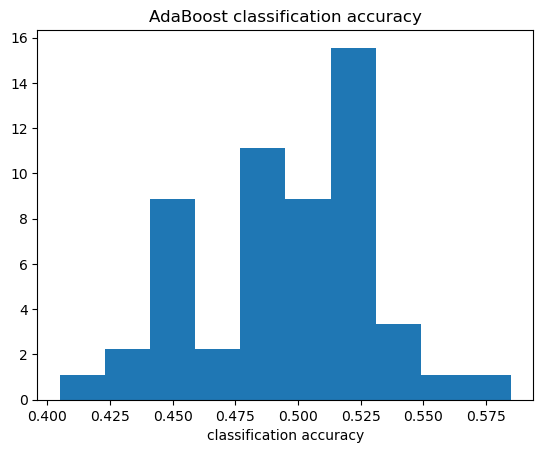

,count,mean,std,min,25%,50%,75%,max
single_tree,50.0,0.5875,0.096390,0.430,0.51000,0.5625,0.67875,0.760
pruned_tree,50.0,0.5817,0.096873,0.420,0.50500,0.5575,0.67250,0.775
rf,50.0,0.8073,0.046699,0.685,0.77250,0.8100,0.84000,0.900
ada,50.0,0.4953,0.035448,0.405,0.47625,0.4950,0.52375,0.585


In [17]:
# high overlap between classes with added noise variables
nrep = 50
n1 = [50, 50]
n2 = [50, 50]
m1 = 20
m0 = 50  
x11 = [-5, 5]
x12 = [5, -5]
x21 = [-5, -5]
x22 = [5, 5]
sd0 = 5

class_sim(nrep, n1, n2, m1, m0, x11, x12, x21, x22, sd0)

With 50 random variables, Random Forest achieves about 81% accuracy, while the other models perform significantly worse.

### Case 6: Classification with 20 Informative Variables and No Noise Variables

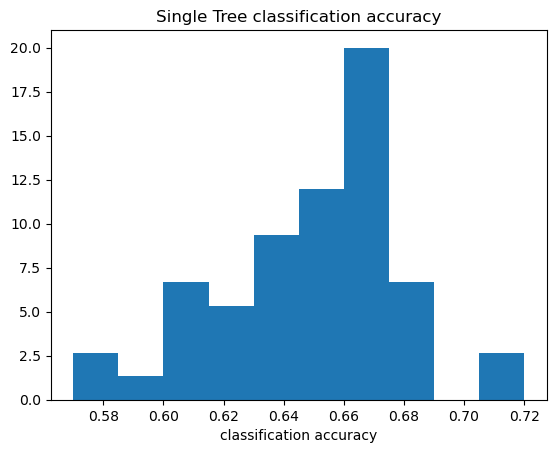

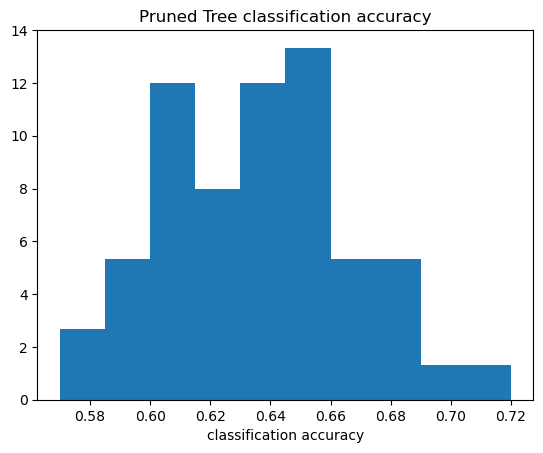

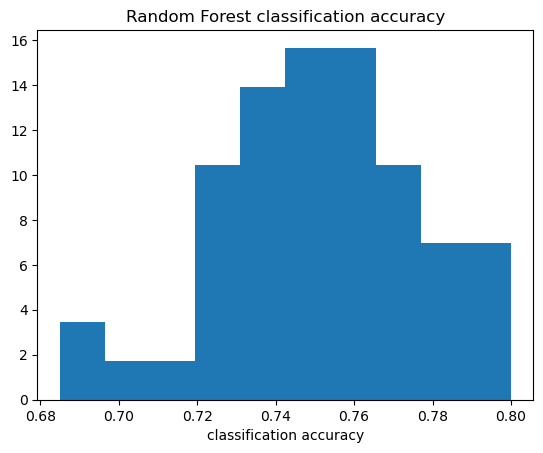

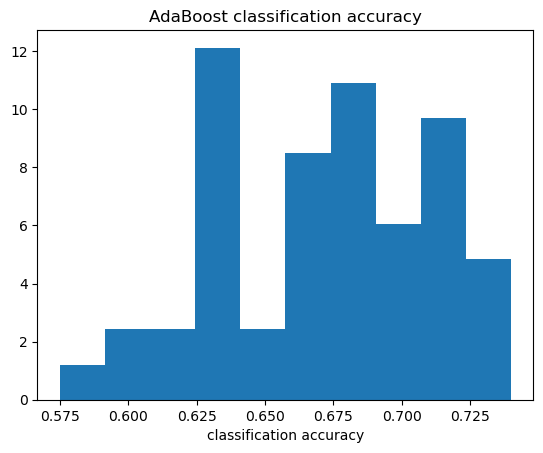

,count,mean,std,min,25%,50%,75%,max
single_tree,50.0,0.6467,0.029857,0.570,0.63500,0.6525,0.66000,0.72
pruned_tree,50.0,0.6354,0.031198,0.570,0.61000,0.6400,0.65375,0.72
rf,50.0,0.7512,0.025745,0.685,0.73625,0.7500,0.77000,0.80
ada,50.0,0.6718,0.038871,0.575,0.64000,0.6750,0.70375,0.74


In [19]:
# imbalanced mixture components within each class
nrep = 50
n1 = [80, 20]
n2 = [20, 80]
m1 = 20
m0 = 0
x11 = [-5, 5]
x12 = [5, -5]
x21 = [-5, -5]
x22 = [5, 5]
sd0 = 10
class_sim(nrep, n1, n2, m1, m0, x11, x12, x21, x22, sd0)

With imbalanced mixture components within each class, the decision tree and AdaBoost perform similarly, while Random Forest performs better than both.

Here, we compare the performance of a single decision tree, a pruned tree, and fine-tuned Random Forest and AdaBoost models. The experimental results show that, for Gaussian data, both fine-tuned Random Forest and AdaBoost achieve similar accuracy, although Random Forest slightly outperforms AdaBoost. However, for a mixture of Gaussians, AdaBoost performs the worst among all models, while Random Forest remains the best-performing model. This pattern holds across all scenarios, both with only informative variables and with additional noise variables.